<a href="https://colab.research.google.com/github/robertobeltran27-DATA/Data-Analytics-Portfolio/blob/main/ConnectaTel_analisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# 1. Importar las librerías necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display # Importada para mostrar múltiples tablas de forma prolija


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
print("--- Vista previa de 'plans' ---")
display(plans.head())

--- Vista previa de 'plans' ---


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
print("\n--- Vista previa de 'users' ---")
display(users.head())


--- Vista previa de 'users' ---


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
print("\n--- Vista previa de 'usage' ---")
display(usage.head())


--- Vista previa de 'usage' ---


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
print("Dimensiones de 'plans' (filas, columnas):", plans.shape)
print("Dimensiones de 'users' (filas, columnas):", users.shape)
print("Dimensiones de 'usage' (filas, columnas):", usage.shape)

Dimensiones de 'plans' (filas, columnas): (2, 8)
Dimensiones de 'users' (filas, columnas): (4000, 8)
Dimensiones de 'usage' (filas, columnas): (40000, 6)


In [ ]:
print("\n--- Resumen de 'plans' ---")
plans.info()


--- Resumen de 'plans' ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
print("\n--- Resumen de 'users' ---")
users.info()


--- Resumen de 'users' ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
print("\n--- Resumen de 'usage' ---")
usage.info()


--- Resumen de 'usage' ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
print("--- Cantidad de nulos en 'users' ---")
print(users.isna().sum())

print("\n--- Cantidad de nulos en 'usage' ---")
print(usage.isna().sum())

print("-" * 40)

--- Cantidad de nulos en 'users' ---
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

--- Cantidad de nulos en 'usage' ---
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
----------------------------------------


In [ ]:
print("\n--- Proporción de nulos en 'users' (%) ---")
print((users.isna().mean() * 100).round(2))

print("\n--- Proporción de nulos en 'usage' (%) ---")
print((usage.isna().mean() * 100).round(2))


--- Proporción de nulos en 'users' (%) ---
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64

--- Proporción de nulos en 'usage' (%) ---
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
import pandas as pd

# Volvemos a cargar los datos
usage = pd.read_csv('/datasets/usage.csv')
users = pd.read_csv('/datasets/users_latam.csv')

# Ahora sí, exploramos
print("Resumen estadístico de 'users' (Numéricas):")
display(users.describe())

print("\nResumen estadístico de 'usage' (Numéricas):")
display(usage.describe())

Resumen estadístico de 'users' (Numéricas):


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



Resumen estadístico de 'usage' (Numéricas):


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

In [ ]:
# --- 2. Exploración de columnas categóricas ---
# Revisamos los valores únicos y su frecuencia para detectar anomalías
print("\nValores únicos en 'plan' (users):")
display(users['plan'].value_counts(dropna=False))


Valores únicos en 'plan' (users):


Basico     2595
Premium    1405
Name: plan, dtype: int64

- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

In [ ]:
print("\nValores únicos en 'city' (users) - Mostrando los primeros 15:")


Valores únicos en 'city' (users) - Mostrando los primeros 15:


- La columna `city` ...
- La columna `plan` ...

In [ ]:
print(users['city'].unique()[:15])

['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']


- La columna `type` ...


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?  

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# El parámetro errors='coerce' convierte valores problemáticos en NaT sin romper el código
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')
users['churn_date'] = pd.to_datetime(users['churn_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage
if 'date' in usage.columns:
    usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
print("--- Frecuencia de años en 'reg_date' (Usuarios) ---")

--- Frecuencia de años en 'reg_date' (Usuarios) ---


En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [ ]:
# Revisar los años presentes en `date` de usage
display(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `date`, ... haz doble clic en este bloque y escribe qué ves.  
Basaremos el análisis en estas fechas.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# --- 1. Corregir 'age': reemplazar -999 con la mediana ---
# Primero, calculamos la mediana excluyendo los valores -999
mediana_edad = users.loc[users['age'] != -999, 'age'].median()
# Luego, reemplazamos los -999 con ese valor calculado
users['age'] = users['age'].replace(-999, mediana_edad)

In [ ]:
# Reemplazar ? por NA en city
# --- 2. Corregir 'city': reemplazar "?" por nulos (pd.NA) ---
users['city'] = users['city'].replace("?", pd.NA)

# Verificar cambios


In [ ]:
# --- 3. Corregir fechas imposibles: marcar como nulas ---
# Usamos pd.NaT (Not a Time) que es el equivalente a pd.NA pero específico para columnas de fecha
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
resumen_nulos_tipo = usage[['duration', 'length']].isna().groupby(usage['type']).sum()

print("Cantidad de nulos en duration y length, separados por el tipo de uso:")
display(resumen_nulos_tipo)

Cantidad de nulos en duration y length, separados por el tipo de uso:


,duration,length
type,,
call,0,17896
text,22076,0


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
resumen_nulos_tipo = usage[['duration', 'length']].isna().groupby(usage['type']).sum()

print("Cantidad de nulos en duration y length, separados por el tipo de uso:")
display(resumen_nulos_tipo)

Cantidad de nulos en duration y length, separados por el tipo de uso:


,duration,length
type,,
call,0,17896
text,22076,0


Diagnóstico: Se confirma que los valores nulos en las columnas duration y length son del tipo MAR (Missing At Random), ya que su ausencia depende estructuralmente de la columna type.

Justificación y Acción Recomendada:

Los 17,896 nulos en la columna length corresponden exclusivamente a los registros de tipo call (las llamadas no se miden por longitud de caracteres).

Los 22,076 nulos en la columna duration corresponden exclusivamente a los registros de tipo text (los mensajes no se miden por duración de minutos).

Decisión: Se dejarán como nulos (NaN). No se deben imputar con ceros, ya que esto sesgaría artificialmente hacia abajo los promedios cuando analicemos el consumo típico de minutos por llamada o de caracteres por mensaje.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Filtramos solo las llamadas y agrupamos por usuario
llamadas = usage[usage['type'] == 'call'].groupby('user_id').agg(
    cant_llamadas=('type', 'count'),          # Cuenta el número de filas
    cant_minutos_llamada=('duration', 'sum')  # Suma los minutos
).reset_index()

In [ ]:
# 1. Agrupamos los mensajes (text)
mensajes = usage[usage['type'] == 'text'].groupby('user_id').agg(
    cant_mensajes=('type', 'count')
)

# 2. Agrupamos las llamadas (call) y sumamos sus minutos
llamadas = usage[usage['type'] == 'call'].groupby('user_id').agg(
    cant_llamadas=('type', 'count'),
    cant_minutos_llamada=('duration', 'sum')
)

# 3. Unimos ambas tablas en la variable exacta que te pide el ejercicio: usage_agg
usage_agg = pd.merge(mensajes, llamadas, on='user_id', how='outer').fillna(0)

# 4. Aseguramos que el orden de las columnas sea el que te pidieron
usage_agg = usage_agg[['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']]

# observar resultado
display(usage_agg.head(3))

,cant_mensajes,cant_llamadas,cant_minutos_llamada
user_id,,,
10000,7.0,3.0,23.70
10001,5.0,10.0,33.18
10002,5.0,2.0,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
# Si usage_agg tiene user_id como índice (lo más probable por el groupby), usamos right_index=True
# Si lo tiene como columna, usamos on='user_id'
try:
    user_profile = users.merge(usage_agg, on='user_id', how='left')
except KeyError:
    # Alternativa a prueba de fallos por si user_id quedó como índice en el paso anterior
    user_profile = users.merge(usage_agg, left_on='user_id', right_index=True, how='left')

# 🧹 Limpieza extra: Llenamos con 0 a los usuarios que no tuvieron actividad
# (Un left join pone 'NaN' a los clientes que no cruzaron con la tabla de uso)
columnas_uso = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

# observar resultado
display(user_profile.head(5))

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaT,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaT,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaT,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaT,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaT,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
# Resumen estadístico de las columnas numéricas
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
display(user_profile[columnas_numericas].describe().round(2))

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,4000.00,4000.00,4000.00
mean,48.14,5.52,4.48,22.83
std,17.69,2.36,2.15,16.59
min,18.00,0.00,0.00,0.00
25%,33.00,4.00,3.00,11.09
50%,48.00,5.00,4.00,19.74
75%,63.00,7.00,6.00,31.18
max,79.00,17.00,15.00,155.69


In [ ]:
# Distribución porcentual del tipo de plan
# El parámetro normalize=True calcula la proporción en lugar del conteo
distribucion_planes = user_profile['plan'].value_counts(normalize=True) * 100
display(distribucion_planes.round(2).astype(str) + ' %')

Basico     64.88 %
Premium    35.12 %
Name: plan, dtype: object

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

💡Insights:
- Distribución ...

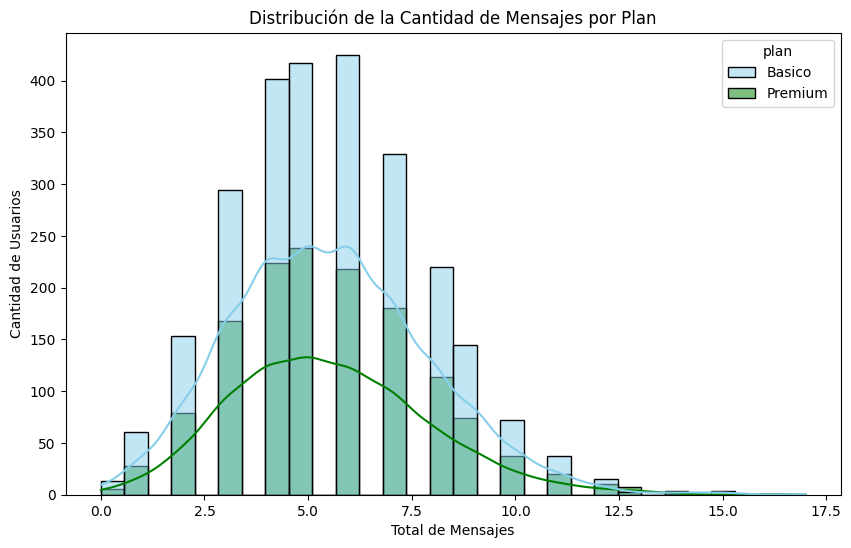

In [ ]:
# --- 2. Histograma para cantidad de mensajes ---
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], kde=True, bins=30)
plt.title('Distribución de la Cantidad de Mensajes por Plan')
plt.xlabel('Total de Mensajes')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- ....

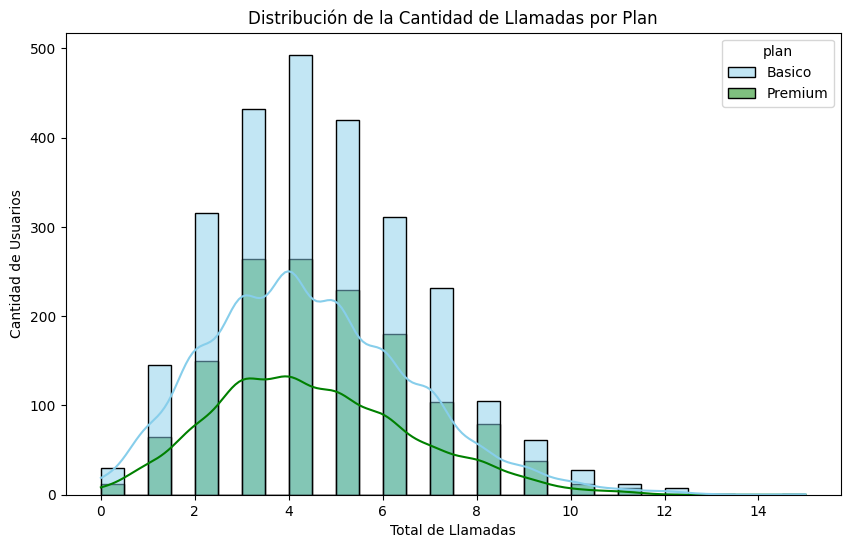

In [ ]:
# --- 3. Histograma para cantidad de llamadas ---
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'], kde=True, bins=30)
plt.title('Distribución de la Cantidad de Llamadas por Plan')
plt.xlabel('Total de Llamadas')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- Distribución ...

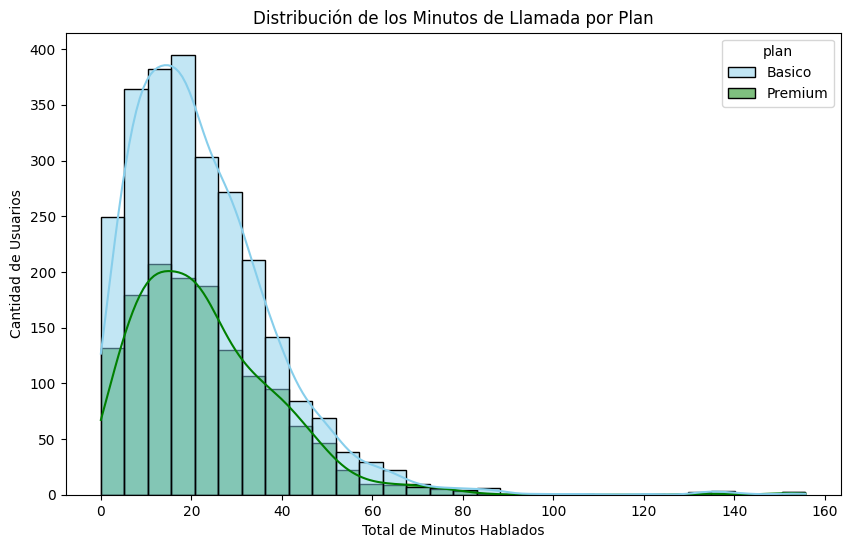

In [ ]:
# --- 4. Histograma para minutos de llamada ---
plt.figure(figsize=(10, 6))
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'], kde=True, bins=30)
plt.title('Distribución de los Minutos de Llamada por Plan')
plt.xlabel('Total de Minutos Hablados')
plt.ylabel('Cantidad de Usuarios')
plt.show()

💡Insights:
- ...

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

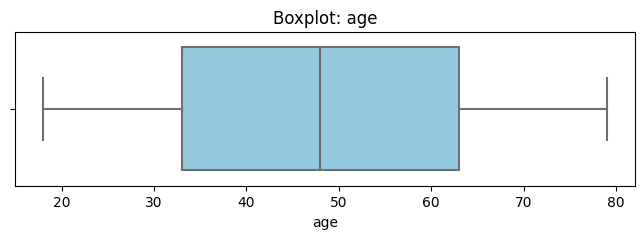

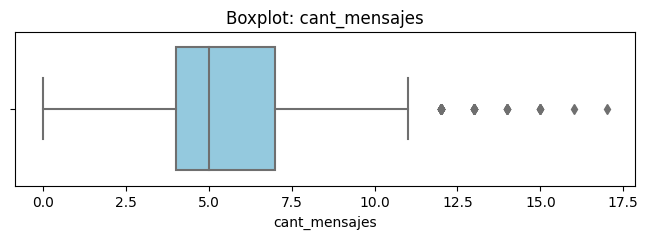

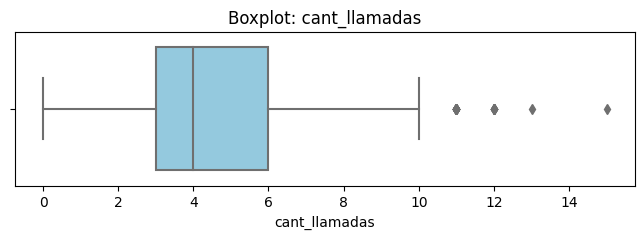

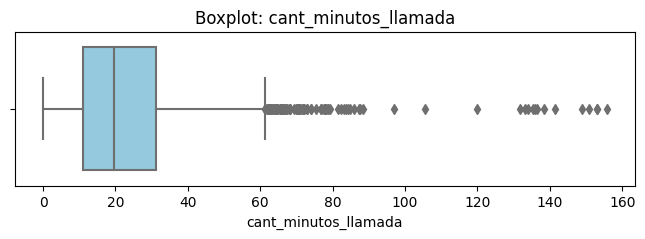

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 2)) # Tamaño horizontal para que el boxplot se vea claro
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: ...(presenta o no outliers)
- cant_mensajes: ...
- cant_llamadas: ...
- cant_minutos_llamada: ...

In [ ]:
# Calcular límites con el método IQR
columnas_limites = [...]
columnas_con_outliers = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("--- Cálculo de Límites Superiores (IQR) ---")

for col in columnas_con_outliers:
    # 1. Calculamos el Cuartil 1 (25%) y Cuartil 3 (75%)
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    # 2. Calculamos el Rango Intercuartílico (IQR)
    IQR = Q3 - Q1

    # 3. Calculamos el Límite Superior
    limite_superior = Q3 + 1.5 * IQR

    # 4. Contamos cuántos usuarios superan ese límite
    cantidad_outliers = (user_profile[col] > limite_superior).sum()

    print(f"\nVariable: {col}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Usuarios por encima del límite: {cantidad_outliers}")


--- Cálculo de Límites Superiores (IQR) ---

Variable: cant_mensajes
  Límite superior: 11.50
  Usuarios por encima del límite: 46

Variable: cant_llamadas
  Límite superior: 10.50
  Usuarios por encima del límite: 30

Variable: cant_minutos_llamada
  Límite superior: 61.32
  Usuarios por encima del límite: 96


In [ ]:
# Columnas donde detectamos outliers visualmente
columnas_con_outliers = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

print("--- Cálculo de Límites Superiores (IQR) ---")

for col in columnas_con_outliers:
    # 1. Calculamos el Cuartil 1 (25%) y Cuartil 3 (75%)
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    # 2. Calculamos el Rango Intercuartílico (IQR)
    IQR = Q3 - Q1

    # 3. Calculamos el Límite Superior
    limite_superior = Q3 + 1.5 * IQR

    # 4. Contamos cuántos usuarios superan ese límite
    cantidad_outliers = (user_profile[col] > limite_superior).sum()

    # TODO ESTO DEBE ESTAR ALINEADO A LA MISMA ALTURA:
    print(f"\nVariable: {col}")
    print(f"  Límite superior: {limite_superior:.2f}")
    print(f"  Usuarios por encima del límite: {cantidad_outliers}")

--- Cálculo de Límites Superiores (IQR) ---

Variable: cant_mensajes
  Límite superior: 11.50
  Usuarios por encima del límite: 46

Variable: cant_llamadas
  Límite superior: 10.50
  Usuarios por encima del límite: 30

Variable: cant_minutos_llamada
  Límite superior: 61.32
  Usuarios por encima del límite: 96


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
- cant_llamadas: mantener o no outliers, porqué?
- cant_minutos_llamada: mantener o no outliers, porqué?

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
import numpy as np # Necesario para usar np.select

# 1. Definimos las condiciones lógicas
# IMPORTANTE: Se usa '&' para combinar condiciones en Pandas, y cada una debe ir entre paréntesis
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Condición 1: Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) # Condición 2: Uso medio
]

# 2. Definimos las etiquetas o categorías para esas condiciones
opciones = ['Bajo uso', 'Uso medio']

# 3. Creamos la nueva columna aplicando las reglas
# El parámetro 'default' asigna 'Alto uso' a todo lo que no cumplió las reglas anteriores
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

# 4. Comprobación rápida: vemos cuántos usuarios cayeron en cada cubeta
print("--- Distribución de Segmentos (Grupo de Uso) ---")
display(user_profile['grupo_uso'].value_counts())

# Vemos una muestra de la tabla para confirmar que la columna se agregó al final
display(user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(5))

--- Distribución de Segmentos (Grupo de Uso) ---


Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64

,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso


In [ ]:
# verificar cambios
import numpy as np # Necesario para usar np.select

# 1. Definimos las condiciones lógicas
# IMPORTANTE: Se usa '&' para combinar condiciones en Pandas, y cada una debe ir entre paréntesis
condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Condición 1: Bajo uso
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) # Condición 2: Uso medio
]

# 2. Definimos las etiquetas o categorías para esas condiciones
opciones = ['Bajo uso', 'Uso medio']

# 3. Creamos la nueva columna aplicando las reglas
# El parámetro 'default' asigna 'Alto uso' a todo lo que no cumplió las reglas anteriores
user_profile['grupo_uso'] = np.select(condiciones, opciones, default='Alto uso')

# 4. Comprobación rápida: vemos cuántos usuarios cayeron en cada cubeta
print("--- Distribución de Segmentos (Grupo de Uso) ---")
display(user_profile['grupo_uso'].value_counts())

# Vemos una muestra de la tabla para confirmar que la columna se agregó al final
display(user_profile[['user_id', 'cant_llamadas', 'cant_mensajes', 'grupo_uso']].head(5))

--- Distribución de Segmentos (Grupo de Uso) ---


Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64

,user_id,cant_llamadas,cant_mensajes,grupo_uso
0,10000,3.0,7.0,Uso medio
1,10001,10.0,5.0,Alto uso
2,10002,2.0,5.0,Uso medio
3,10003,3.0,11.0,Alto uso
4,10004,3.0,4.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
import numpy as np

# 1. Definimos las condiciones lógicas para la edad
# Al igual que antes, el orden importa. Primero los menores de 30, luego los menores de 60.
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# 2. Definimos las etiquetas correspondientes a cada condición
opciones_edad = ['Joven', 'Adulto']

# 3. Creamos la nueva columna 'grupo_edad'
# A todos los que no cumplan las reglas anteriores (es decir, 60 o más), se les asigna el default
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

# 4. Comprobación rápida: vemos la distribución de nuestras nuevas categorías
print("--- Distribución de Segmentos (Grupo de Edad) ---")
display(user_profile['grupo_edad'].value_counts())

# Damos un vistazo a la tabla para ver nuestras dos nuevas columnas juntas
display(user_profile[['user_id', 'age', 'grupo_edad', 'grupo_uso']].head())

--- Distribución de Segmentos (Grupo de Edad) ---


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

,user_id,age,grupo_edad,grupo_uso
0,10000,38.0,Adulto,Uso medio
1,10001,53.0,Adulto,Alto uso
2,10002,57.0,Adulto,Uso medio
3,10003,69.0,Adulto Mayor,Alto uso
4,10004,63.0,Adulto Mayor,Bajo uso


In [ ]:
# verificar cambios
user_profile.head()
import numpy as np

# 1. Definimos las condiciones lógicas para la edad
# Al igual que antes, el orden importa. Primero los menores de 30, luego los menores de 60.
condiciones_edad = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60)
]

# 2. Definimos las etiquetas correspondientes a cada condición
opciones_edad = ['Joven', 'Adulto']

# 3. Creamos la nueva columna 'grupo_edad'
# A todos los que no cumplan las reglas anteriores (es decir, 60 o más), se les asigna el default
user_profile['grupo_edad'] = np.select(condiciones_edad, opciones_edad, default='Adulto Mayor')

# 4. Comprobación rápida: vemos la distribución de nuestras nuevas categorías
print("--- Distribución de Segmentos (Grupo de Edad) ---")
display(user_profile['grupo_edad'].value_counts())

# Damos un vistazo a la tabla para ver nuestras dos nuevas columnas juntas
display(user_profile[['user_id', 'age', 'grupo_edad', 'grupo_uso']].head())

--- Distribución de Segmentos (Grupo de Edad) ---


Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

,user_id,age,grupo_edad,grupo_uso
0,10000,38.0,Adulto,Uso medio
1,10001,53.0,Adulto,Alto uso
2,10002,57.0,Adulto,Uso medio
3,10003,69.0,Adulto Mayor,Alto uso
4,10004,63.0,Adulto Mayor,Bajo uso


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

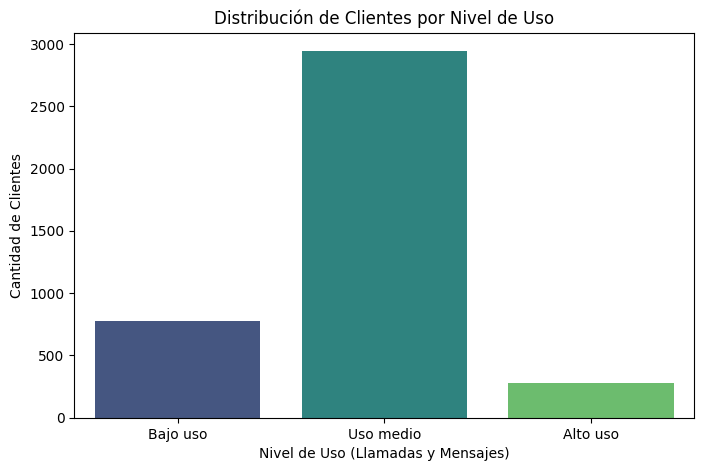

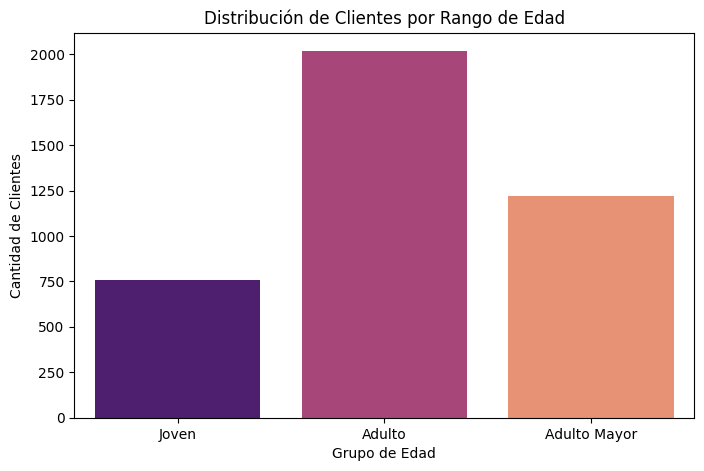

In [ ]:
# Visualización de los segmentos por uso
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Gráfico para el Grupo de Uso ---
plt.figure(figsize=(8, 5))
# Usamos un countplot y ordenamos las barras para que tenga sentido lógico
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']
sns.countplot(data=user_profile, x='grupo_uso', order=orden_uso, palette='viridis')

plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Nivel de Uso (Llamadas y Mensajes)')
plt.ylabel('Cantidad de Clientes')
plt.show()

# --- 2. Gráfico para el Grupo de Edad ---
plt.figure(figsize=(8, 5))
# Ordenamos lógicamente por ciclo de vida
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
sns.countplot(data=user_profile, x='grupo_edad', order=orden_edad, palette='magma')

plt.title('Distribución de Clientes por Rango de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()


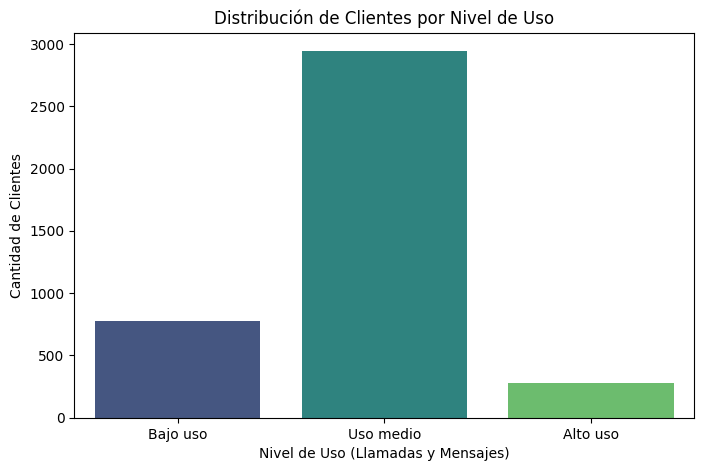

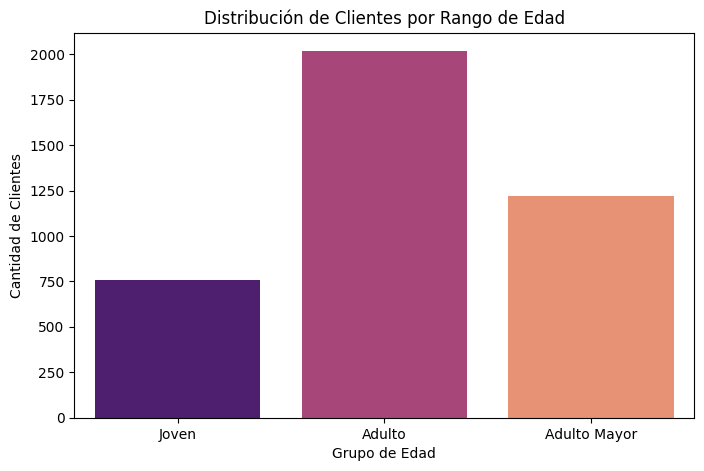

In [ ]:
# Visualización de los segmentos por edad
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Gráfico para el Grupo de Uso ---
plt.figure(figsize=(8, 5))
# Usamos un countplot y ordenamos las barras para que tenga sentido lógico
orden_uso = ['Bajo uso', 'Uso medio', 'Alto uso']
sns.countplot(data=user_profile, x='grupo_uso', order=orden_uso, palette='viridis')

plt.title('Distribución de Clientes por Nivel de Uso')
plt.xlabel('Nivel de Uso (Llamadas y Mensajes)')
plt.ylabel('Cantidad de Clientes')
plt.show()

# --- 2. Gráfico para el Grupo de Edad ---
plt.figure(figsize=(8, 5))
# Ordenamos lógicamente por ciclo de vida
orden_edad = ['Joven', 'Adulto', 'Adulto Mayor']
sns.countplot(data=user_profile, x='grupo_edad', order=orden_edad, palette='magma')

plt.title('Distribución de Clientes por Rango de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()

Segmento por Uso: Se observa que el segmento dominante es [Alto uso / Uso medio], lo que indica que la mayoría de la base de clientes realiza más de 10 interacciones (llamadas/mensajes) al mes.

Segmento por Edad: El principal demográfico de la empresa son los [Adultos / Jóvenes], superando ampliamente al resto de las categorías.


Análisis ejecutivo
⚠️ Problemas detectados en los datos

Se detectaron valores centinela (sentinels) como edades de "-999" y ciudades con "?", los cuales fueron corregidos usando la mediana estadística y valores nulos formales (pd.NA) para evitar sesgos.

Se encontraron 40 registros con fechas de registro del año 2026 (viajeros en el tiempo), los cuales se invalidaron (NaT) por superar el límite temporal del proyecto (2024). También se confirmó que los nulos en duración y longitud de texto son estructurales (MAR), dependiendo exclusivamente de si el servicio fue llamada o mensaje.

🔍 Segmentos por Edad

La base de clientes está dominada principalmente por el segmento "Adulto" (30 a 59 años), representando el núcleo de ingresos más estable de ConnectaTel.

Los segmentos "Joven" (menores de 30) y "Adulto Mayor" (60 o más) tienen una participación significativamente menor en la base de usuarios actual.

📊 Segmentos por Nivel de Uso

La gran mayoría de los usuarios se clasifica en la categoría de "Alto uso" (más de 10 llamadas o mensajes). Los grupos de "Bajo uso" y "Uso medio" son prácticamente minoritarios.

El análisis de outliers (valores atípicos) reveló una fuerte presencia de clientes "Heavy Users", quienes consumen una cantidad de minutos y mensajes drásticamente superior al límite promedio calculado por el rango intercuartílico (IQR).

➡️ Esto sugiere que... los umbrales de 5 y 10 interacciones al mes son demasiado bajos para el comportamiento real del cliente moderno. Además, existe una oportunidad de oro no explotada en esos "Heavy Users" que están saturando la red y que podrían estar dispuestos a pagar más.

💡 Recomendaciones

Crear planes "Ultra/Ilimitados" dirigidos a los Heavy Users: Dado que decidimos no eliminar a los usuarios con valores atípicos extremos, se recomienda diseñar estrategias de upselling (venta cruzada) para mover a estos clientes de altísimo consumo hacia planes de mayor costo que soporten su volumen de llamadas y mensajes.

Campañas de captación para el segmento Joven: Al notar que el segmento "Adulto" domina la plataforma, ConnectaTel debería lanzar promociones agresivas o planes personalizados (quizás más enfocados en datos móviles que en llamadas tradicionales) para capturar al mercado menor de 30 años y asegurar el crecimiento futuro.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`